<a href="https://colab.research.google.com/github/SriSharanya-617/deeplearning/blob/main/nltk_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Shape: (5572, 5)

Spam vs Ham count:
label
ham     4825
spam     747
Name: count, dtype: int64

Average length: 80.11880832735105


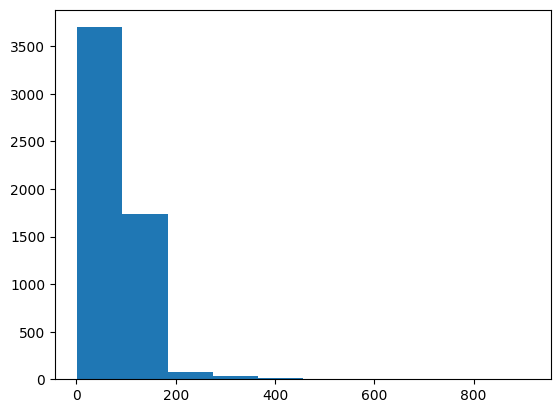

[('to', 2134), ('you', 1622), ('I', 1466), ('a', 1327), ('the', 1197), ('and', 857), ('in', 798), ('is', 781), ('i', 742), ('u', 692)]


In [18]:
from collections import Counter

df = pd.read_csv('/content/drive/My Drive/spamm.csv',encoding='latin-1')

df = df.rename(columns={"v1": "label", "v2": "message"})

print("Shape:", df.shape);

print("\nSpam vs Ham count:")
print(df["label"].value_counts())

df["length"] = df["message"].astype(str).apply(len)

print("\nAverage length:", df["length"].mean())

plt.hist(df["length"])
plt.show()

all_words = " ".join(df["message"].astype(str)).split()
freq = Counter(all_words)

print(freq.most_common(10))

In [19]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [20]:
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# download once
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess(text):

    # Lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # join again
    cleaned_text = " ".join(tokens)

    return cleaned_text


# test
print(preprocess("I am Loving the NLP class!!! It is amazing."))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


loving nlp class amazing


In [22]:
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# load dataset
df = pd.read_csv("/content/drive/MyDrive/spamm.csv", encoding="latin-1")

df = df.rename(columns={"v1": "label", "v2": "message"})

X = df["message"].astype(str)
y = df["label"]


# ---------- BoW ----------
bow = CountVectorizer()

X_bow = bow.fit_transform(X)

print("BoW feature size:", X_bow.shape)


# ---------- TF-IDF ----------
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

print("TFIDF feature size:", X_tfidf.shape)


# ---------- Train test split ----------
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


# ---------- Model ----------
model1 = MultinomialNB()
model1.fit(X_train_bow, y_train)

pred1 = model1.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, pred1))


model2 = MultinomialNB()
model2.fit(X_train_tfidf, y_train)

pred2 = model2.predict(X_test_tfidf)

print("TFIDF Accuracy:", accuracy_score(y_test, pred2))

BoW feature size: (5572, 8672)
TFIDF feature size: (5572, 8672)
BoW Accuracy: 0.97847533632287
TFIDF Accuracy: 0.9623318385650225


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

vec = TfidfVectorizer()
X_vec = vec.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.9632286995515695
[[965   0]
 [ 41 109]]


In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

models = {
    "NB": MultinomialNB(),
    "LR": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    print(name)
    print(classification_report(y_test, p))

NB
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

LR
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

SVM
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       965
        spam       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [25]:
from sklearn.model_selection import GridSearchCV

param = {"C":[0.1,1,10]}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 10}


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(ngram_range=(1,2))
X_vec = vec.fit_transform(X)

vec2 = TfidfVectorizer(ngram_range=(1,3))
X_vec2 = vec2.fit_transform(X)

print(X_vec.shape)
print(X_vec2.shape)

(5572, 50326)
(5572, 104564)


In [27]:
from textblob import TextBlob

df["sentiment"] = df["message"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print(df[["message","sentiment"]].head())

                                             message  sentiment
0  Go until jurong point, crazy.. Available only ...       0.15
1                      Ok lar... Joking wif u oni...       0.50
2  Free entry in 2 a wkly comp to win FA Cup fina...       0.30
3  U dun say so early hor... U c already then say...       0.10
4  Nah I don't think he goes to usf, he lives aro...       0.00


In [31]:
import nltk
from nltk import pos_tag, word_tokenize

nltk.download('averaged_perceptron_tagger_eng')

text = "Win money now"

tokens = word_tokenize(text)

print(pos_tag(tokens))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


[('Win', 'NNP'), ('money', 'NN'), ('now', 'RB')]


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [32]:
from nltk.util import bigrams

text = "win money now win prize now".split()

bg = list(bigrams(text))

print(bg)

[('win', 'money'), ('money', 'now'), ('now', 'win'), ('win', 'prize'), ('prize', 'now')]


In [33]:
from collections import Counter

c = Counter(bg)
print(c)

Counter({('win', 'money'): 1, ('money', 'now'): 1, ('now', 'win'): 1, ('win', 'prize'): 1, ('prize', 'now'): 1})
